#### Imports & Configurações

In [1]:
# =========================
# Bloco 0 — Imports & Setup
# =========================
#import os
from pathlib import Path
import json
#import numpy as np
import pandas as pd
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt
import warnings
#import mlflow.pyfunc
#import mlflow.sklearn
#import mlflow.xgboost

import mlflow
#import mlflow.sklearn
#import mlflow.xgboost
#from mlflow.tracking import MlflowClient

from sklearn.pipeline import Pipeline

# SHAP
# (se não estiver instalado: !pip install shap)
import shap
shap.initjs()

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# --- Caminhos principais ---
DATA_FULL = Path("dados/online_shoppers_intention.csv")  # dataset completo (histórico)
MLRUNS_DIR = Path("mlruns")                              # pasta local do MLflow tracking

# --- Corrigir URI no Windows (usa Path.as_uri) ---
mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
print("MLflow tracking URI:", mlflow.get_tracking_uri())

# --- Run IDs dos modelos vencedores (oversampling/undersampling) ---
RUN_ID_RF  = "7bd415c0b41141fd9cf0fbe881c2493b"  # under__rf
RUN_ID_XGB = "a15d0102fc1042b3857ede82117fec81"  # under__xgb

# (Opcional) limitar amostra para SHAP (para evitar ficar pesado)
SHAP_SAMPLE = 800


MLflow tracking URI: file:///D:/Drive/Academico/DataScience_XP/ProjetoAplicado/projetoAplicadoDSXP/mlruns


#### Função de encoding (a MESMA do projeto)

In [2]:
# ==========================================
# Bloco 1 — encode_features (MESMA do projeto)
# ==========================================
def encode_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # (a) Month -> ordinal (ordem temporal)
    meses_ordem = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_map = {m: i + 1 for i, m in enumerate(meses_ordem)}  # Feb=1, Mar=2, ... Dec=10
    df['Month'] = df['Month'].map(month_map).astype('int64')

    # (b) VisitorType -> One-Hot (base = New)
    df['VisitorType'] = df['VisitorType'].replace({
        'Returning_Visitor': 'Returning',
        'New_Visitor': 'New',
        'Other': 'Other'
    })
    df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)
    # Colunas criadas: VisitorType_Other, VisitorType_Returning (base implícita = New)

    # (c) Weekend -> garantir inteiro
    if df['Weekend'].dtype not in ['int64', 'int32']:
        df['Weekend'] = df['Weekend'].astype(int)

    return df


#### Carregar dataset completo e preparar X

In [3]:
# ====================================================
# Bloco 2 — Carregar dataset completo e preparar dados
# ====================================================
if not DATA_FULL.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {DATA_FULL}")

df_full = pd.read_csv(DATA_FULL, encoding="utf-8")
df_enc  = encode_features(df_full)

has_target = "Revenue" in df_enc.columns
if has_target:
    y = df_enc["Revenue"].astype(int).values
    X = df_enc.drop(columns=["Revenue"]).copy()
else:
    y = None
    X = df_enc.copy()

print("Shape X:", X.shape, "| target presente?", has_target)
print("Colunas X (amostra):", list(X.columns)[:10], "...")


Shape X: (12330, 18) | target presente? True
Colunas X (amostra): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'] ...


#### Utilitários para alinhar features ao que o modelo espera

In [4]:
# =========================================================================
# Bloco 3 — Descobrir e alinhar as features usadas no treino (robusto)
# =========================================================================
from mlflow.tracking import MlflowClient
client = MlflowClient()

def list_artifacts_recursive(run_id, path=""):
    """Lista artefatos de forma recursiva (todas as subpastas)."""
    out = []
    stack = [path]
    while stack:
        p = stack.pop()
        for a in client.list_artifacts(run_id, p):
            if a.is_dir:
                stack.append(a.path)
            else:
                out.append(a.path)
    return out

def load_feature_list_from_run(run_id):
    """
    Procura por 'feature_cols.json' em qualquer subpasta do run.
    Se encontrar, carrega e retorna a lista de colunas.
    """
    try:
        all_files = list_artifacts_recursive(run_id, "")
        cand = [p for p in all_files if p.endswith("feature_cols.json")]
        if cand:
            tmp_dir = Path(f"tmp_artifacts_{run_id}")
            tmp_dir.mkdir(exist_ok=True)
            client.download_artifacts(run_id, cand[0], str(tmp_dir))
            with open(tmp_dir / Path(cand[0]).name, "r", encoding="utf-8") as f:
                return json.load(f)
        return None
    except Exception as e:
        print(f"[warn] Falha ao buscar feature_cols.json no run {run_id}: {e}")
        return None

def get_feature_names_from_model(model):
    """
    Tenta obter os nomes das features diretamente do modelo (sklearn >=1.0).
    """
    try:
        est = model.steps[-1][1] if isinstance(model, Pipeline) else model
        if hasattr(est, "feature_names_in_"):
            return list(est.feature_names_in_)
        return None
    except Exception:
        return None

def align_X_to_feature_list(X_in: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    """
    Alinha X exatamente para 'feature_list': adiciona colunas faltantes=0,
    reordena, e remove extras.
    """
    X = X_in.copy()
    for c in feature_list:
        if c not in X.columns:
            X[c] = 0
    X = X[feature_list]  # reordena e descarta extras
    return X


#### Carregar modelos (robusto a flavors)

In [5]:
# ======================================================
# Bloco 4 — Carregar modelos e alinhar X com features do treino
# ======================================================


def load_model_any(model_uri: str):
    """Tenta carregar via sklearn → xgboost → pyfunc (primeiro que funcionar)."""
    for loader in (mlflow.sklearn.load_model, mlflow.xgboost.load_model, mlflow.pyfunc.load_model):
        try:
            return loader(model_uri)
        except Exception:
            continue
    raise RuntimeError(f"Não foi possível carregar o modelo em {model_uri} via sklearn/xgboost/pyfunc.")

# URIs dos runs vencedores
uri_rf  = f"runs:/{RUN_ID_RF}/model"
uri_xgb = f"runs:/{RUN_ID_XGB}/model"

rf_model  = load_model_any(uri_rf)
xgb_model = load_model_any(uri_xgb)

# 1) Tentar pegar a lista de features usada no treino (ordem e conteúdo)
rf_feats = load_feature_list_from_run(RUN_ID_RF) or get_feature_names_from_model(rf_model)
xgb_feats = load_feature_list_from_run(RUN_ID_XGB) or get_feature_names_from_model(xgb_model)

# 2) Se ainda não tiver, último recurso: usar as colunas atuais de X (não recomendado, mas evita travar)
if rf_feats is None:
    print("[warn] RF: não achei feature_cols.json nem feature_names_in_. Usando X.columns como fallback.")
    rf_feats = list(X.columns)
if xgb_feats is None:
    print("[warn] XGB: não achei feature_cols.json nem feature_names_in_. Usando X.columns como fallback.")
    xgb_feats = list(X.columns)

# 3) Alinhar X exatamente para a lista de treino de cada modelo
X_rf  = align_X_to_feature_list(X, rf_feats)
X_xgb = align_X_to_feature_list(X, xgb_feats)

print("X_rf shape:", X_rf.shape, "| n_feats_treino RF:", len(rf_feats))
print("X_xgb shape:", X_xgb.shape, "| n_feats_treino XGB:", len(xgb_feats))


X_rf shape: (12330, 23) | n_feats_treino RF: 23
X_xgb shape: (12330, 23) | n_feats_treino XGB: 23


#### Feature Importance (com fallback para pyfunc)

,feature,importance
0,PageValues,0.267760
1,PageValues_Outlier,0.234334
2,Month,0.066377
3,ProductRelated_Duration,0.063667
4,ExitRates,0.057506
5,ProductRelated,0.046696
6,ProductPageViewRate,0.041212
7,BounceRates,0.036230
8,ExitBounceRatio,0.033163
9,Administrative_Duration,0.032716


,feature,importance
0,PageValues_Outlier,0.714588
1,PageValues,0.098980
2,Month,0.046602
3,ProductRelated_Duration_Outlier,0.012855
4,ProductRelated,0.011193
5,VisitorType_Returning,0.010198
6,ProductRelated_Duration,0.009618
7,ExitRates,0.009262
8,BounceRates,0.008942
9,Administrative,0.007447


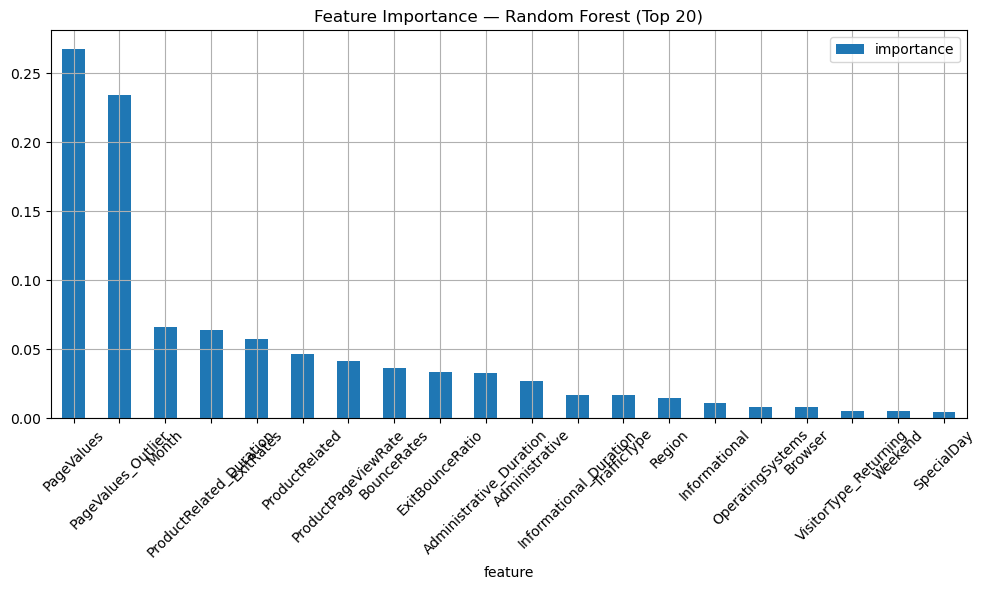

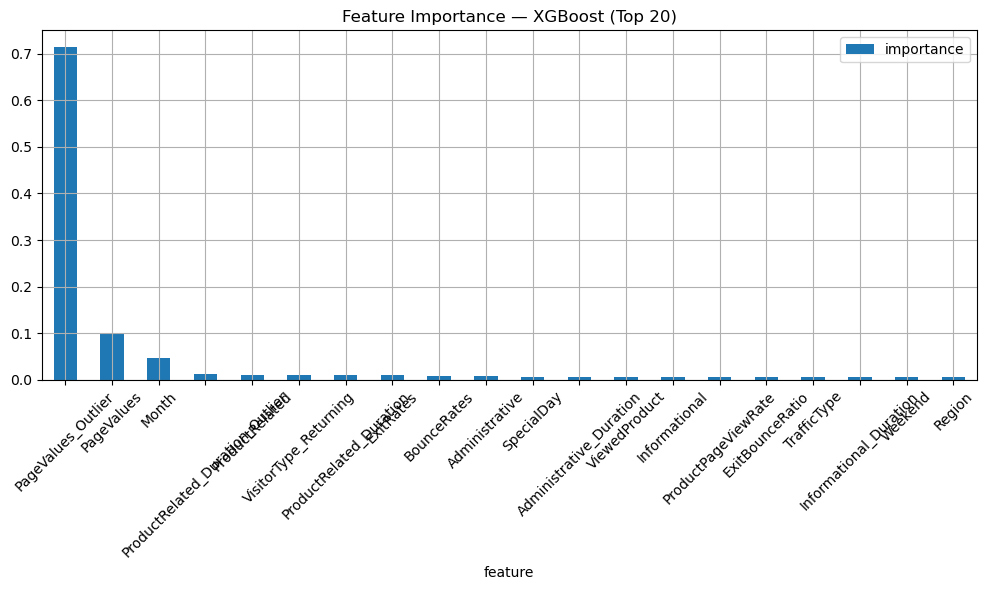

In [6]:
# ============================================================
# Bloco 5 — Feature Importance (FI) com fallback
# ============================================================


def get_estimator(model):
    """Se for Pipeline, pega o último step; senão, retorna o próprio model."""
    if isinstance(model, Pipeline):
        return model.steps[-1][1]
    return model

def _xgb_importance_from_booster(est, feature_names):
    """Extrai importância do XGBoost quando o objeto é um Booster (ou get_booster existe)."""
    booster = est.get_booster() if hasattr(est, "get_booster") else est
    score = booster.get_score(importance_type="gain")
    if not score:
        score = booster.get_score(importance_type="weight")
    mapped = []
    for k, v in score.items():
        if k.startswith("f") and k[1:].isdigit():
            idx = int(k[1:])
            if idx < len(feature_names):
                mapped.append((feature_names[idx], float(v)))
            else:
                mapped.append((k, float(v)))
        else:
            mapped.append((k, float(v)))
    df_imp = pd.DataFrame(mapped, columns=["feature", "importance"]).groupby("feature", as_index=False)["importance"].sum()
    return df_imp

def feature_importance_dataframe(model, X_frame: pd.DataFrame, top_k=20):
    """
    Tenta extrair FI de forma nativa (feature_importances_ para RF/XGBClassifier).
    Se não conseguir (ex.: pyfunc), aplica Permutation Importance como fallback (cuidado: lento).
    """
    est = get_estimator(model)
    feature_names = list(X_frame.columns)

    # Caso 1: FI nativa (mais rápida/estável)
    if hasattr(est, "feature_importances_"):
        fi = np.asarray(est.feature_importances_, dtype=float)
        df_fi = pd.DataFrame({"feature": feature_names, "importance": fi})
        df_fi = df_fi.sort_values("importance", ascending=False).reset_index(drop=True)
        return df_fi.head(top_k)

    # Caso 2: XGB Booster puro
    try:
        df_fi = _xgb_importance_from_booster(est, feature_names)
        df_fi = df_fi.sort_values("importance", ascending=False).reset_index(drop=True)
        return df_fi.head(top_k)
    except Exception:
        pass

    # Caso 3: pyfunc ou outro sem FI — fallback em Permutation Importance
    warnings.warn("Modelo sem 'feature_importances_'. Aplicando Permutation Importance (pode ser lento).")
    # Para PI, precisamos de y — se não houver target no CSV completo, peça para limitar X e y de um subset.
    if y is None:
        raise RuntimeError("Permutation Importance requer 'y'. Recarregue dataset com a coluna target (Revenue).")

    # Amostra para acelerar
    n = min(2000, len(X_frame))
    X_small = X_frame.sample(n, random_state=42)
    y_small = pd.Series(y, index=X_frame.index).loc[X_small.index].values

    # Garantir que o modelo tenha predict ou predict_proba
    def predict_fn(xx):
        # tenta predict_proba[:,1]; se não existir, usa predict
        try:
            p = model.predict_proba(xx)
            if isinstance(p, np.ndarray) and p.ndim == 2 and p.shape[1] >= 2:
                return p[:, 1]
            return model.predict(xx)
        except Exception:
            return model.predict(xx)

    # Wrapper para sklearn PI: precisamos de um estimator-like. Usaremos um “objeto” simples.
    class _EstimatorWrapper:
        def __init__(self, predict_fn):
            self.predict_fn = predict_fn
        def fit(self, X, y):  # compat
            return self
        def predict(self, X):
            return (self.predict_fn(X) > 0.5).astype(int)

    wrapper = _EstimatorWrapper(predict_fn)
    pi = permutation_importance(wrapper, X_small, y_small, scoring="f1", n_repeats=5, random_state=42)
    df_pi = pd.DataFrame({"feature": feature_names, "importance": pi.importances_mean})
    df_pi = df_pi.sort_values("importance", ascending=False).reset_index(drop=True)
    return df_pi.head(top_k)

# === Importâncias (Top 20) ===
fi_rf  = feature_importance_dataframe(rf_model,  X_rf,  top_k=20)
fi_xgb = feature_importance_dataframe(xgb_model, X_xgb, top_k=20)

display(fi_rf)
display(fi_xgb)

# === Plots ===
ax = fi_rf.plot.bar(x="feature", y="importance",
                    title="Feature Importance — Random Forest (Top 20)", rot=45)
plt.tight_layout(); plt.show()

ax = fi_xgb.plot.bar(x="feature", y="importance",
                     title="Feature Importance — XGBoost (Top 20)", rot=45)
plt.tight_layout(); plt.show()
